### Instagram Engagement Analysis Project

#### Objective
- Which post type (reel, image, carousel) performs best in terms of engagement?
- Which posting hour generates the highest engagement rate?
- Which content type achieves the highest reach?
- What factors drive user engagement (likes, comments, shares, saves)?
- Which post type performs best overall when considering multiple metrics?
- How does post type performance vary across different posting times?

In [19]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("C:/Users/hp/Downloads/instagram_engagement_dataset.csv")

In [4]:
#Gattering information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   post_id                120 non-null    int64
 1   date                   120 non-null    str  
 2   post_type              120 non-null    str  
 3   post_time              120 non-null    int64
 4   caption_length         120 non-null    int64
 5   hashtags_count         120 non-null    int64
 6   likes                  120 non-null    int64
 7   comments               120 non-null    int64
 8   shares                 120 non-null    int64
 9   saves                  120 non-null    int64
 10  impressions            120 non-null    int64
 11  reach                  120 non-null    int64
 12  followers_before_post  120 non-null    int64
 13  followers_after_post   120 non-null    int64
dtypes: int64(12), str(2)
memory usage: 13.3 KB


In [5]:
df.head(2)

,post_id,date,post_type,post_time,caption_length,hashtags_count,likes,comments,shares,saves,impressions,reach,followers_before_post,followers_after_post
0,1,2025-02-08,image,14,126,7,1332,86,75,93,12964,9577,10004,10064
1,2,2025-01-22,reel,23,211,11,1432,73,31,133,11130,8314,10006,10032


In [25]:
# Total null values in dataset
df.isnull().sum()

post_id                  0
date                     0
post_type                0
post_time                0
caption_length           0
hashtags_count           0
likes                    0
comments                 0
shares                   0
saves                    0
impressions              0
reach                    0
followers_before_post    0
followers_after_post     0
dtype: int64

In [6]:
df.describe()

,post_id,post_time,caption_length,hashtags_count,likes,comments,shares,saves,impressions,reach,followers_before_post,followers_after_post
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,60.500000,11.516667,164.525000,7.166667,1316.991667,165.991667,74.325000,117.891667,12479.041667,8979.950000,10144.833333,10195.991667
std,34.785054,6.913613,76.682907,4.292525,1050.979059,151.950816,69.280475,112.023392,7709.156976,6010.824183,112.231553,128.575485
min,1.000000,0.000000,20.000000,0.000000,59.000000,3.000000,5.000000,4.000000,1009.000000,725.000000,10003.000000,10016.000000
25%,30.750000,6.000000,104.500000,3.750000,505.500000,61.500000,24.750000,43.000000,5740.250000,4107.250000,10048.000000,10093.000000
50%,60.500000,13.000000,172.500000,7.000000,1024.000000,121.500000,54.500000,77.500000,11949.500000,8247.000000,10116.000000,10166.500000
75%,90.250000,17.000000,222.000000,11.000000,1939.750000,213.250000,102.000000,157.250000,18645.250000,13347.250000,10226.500000,10291.250000
max,120.000000,23.000000,299.000000,14.000000,4870.000000,723.000000,392.000000,702.000000,29704.000000,25058.000000,10456.000000,10676.000000


In [27]:
# Total columns in dataset
df.columns

Index(['post_id', 'date', 'post_type', 'post_time', 'caption_length',
       'hashtags_count', 'likes', 'comments', 'shares', 'saves', 'impressions',
       'reach', 'followers_before_post', 'followers_after_post'],
      dtype='str')

In [7]:
df['engagement_rate'] = (
    df['likes'] + df['comments'] + df['shares'] + df['saves']
) / df['reach']

### Analyzing Dataset

In [8]:
df.groupby("post_type").agg({'engagement_rate':'sum'}).sort_values('engagement_rate',ascending=False)

,engagement_rate
post_type,
reel,9.524568
image,8.406091
carousel,4.891219


In [9]:
df.groupby("post_time").agg({'engagement_rate':'mean'}).sort_values('engagement_rate',ascending=False)

,engagement_rate
post_time,
19,0.323474
4,0.267474
7,0.260295
15,0.244697
10,0.238662
2,0.226571
1,0.217625
21,0.217354
6,0.206244


In [10]:
df.columns

Index(['post_id', 'date', 'post_type', 'post_time', 'caption_length',
       'hashtags_count', 'likes', 'comments', 'shares', 'saves', 'impressions',
       'reach', 'followers_before_post', 'followers_after_post',
       'engagement_rate'],
      dtype='str')

In [36]:
df.groupby("post_type").agg({'reach':'mean'}).sort_values(by ='reach',ascending=False)

,reach
post_type,
reel,11244.196078
carousel,8148.035714
image,6731.585366


In [11]:

df.groupby(['likes','comments','saves','shares']).agg({'engagement_rate':'mean'})

,,,,engagement_rate
likes,comments,saves,shares,
59,3,4,5,0.069745
114,19,16,6,0.132705
115,9,4,8,0.187586
168,14,21,14,0.176136
169,29,21,8,0.084481
...,...,...,...,...
3747,539,127,114,0.244254
3829,490,368,337,0.268247
3846,495,241,129,0.302336


In [38]:
df[['likes','comments','saves','shares','engagement_rate']].corr()

,likes,comments,saves,shares,engagement_rate
likes,1.000000,0.893841,0.847105,0.854578,0.421118
comments,0.893841,1.000000,0.742364,0.792709,0.390940
saves,0.847105,0.742364,1.000000,0.803523,0.385247
shares,0.854578,0.792709,0.803523,1.000000,0.405300
engagement_rate,0.421118,0.390940,0.385247,0.405300,1.000000


In [12]:
df[['likes','comments','saves','shares','engagement_rate']].corr()['engagement_rate'].sort_values(ascending=False)

engagement_rate    1.000000
likes              0.421118
shares             0.405300
comments           0.390940
saves              0.385247
Name: engagement_rate, dtype: float64

In [13]:
df['engagement_rate'] = (
    df['likes'] + df['comments'] + df['shares'] + df['saves']
) / df['reach']

In [14]:
df.groupby('post_type').agg({'likes':'mean','comments':'mean','saves':'mean','shares':'mean','reach':'mean'})

,likes,comments,saves,shares,reach
post_type,,,,,
carousel,1180.535714,149.035714,103.178571,68.857143,8148.035714
image,1066.634146,136.195122,90.097561,55.804878,6731.585366
reel,1593.176471,199.254902,148.313725,92.215686,11244.196078


In [42]:
df.groupby('post_type').agg({'likes':'mean','comments':'mean','saves':'mean','shares':'mean','reach':'mean'}).sort_values(by='likes',ascending=False)
    

,likes,comments,saves,shares,reach
post_type,,,,,
reel,1593.176471,199.254902,148.313725,92.215686,11244.196078
carousel,1180.535714,149.035714,103.178571,68.857143,8148.035714
image,1066.634146,136.195122,90.097561,55.804878,6731.585366


In [15]:
df.groupby(['post_type','post_time']).agg({'engagement_rate':'mean'})

engagement_rate
post_type post_time                 
carousel  0                 0.102078
          1                 0.218678
          2                 0.227567
          3                 0.081752
          4                 0.193772
          6                 0.220792
          8                 0.076537
          9                 0.149878
          11                0.084481
          13                0.144332
          14                0.211790
          16                0.130031
          17                0.225125
          19                0.317836
          20                0.244254
          22                0.101157
image     0                 0.127861
          1                 0.154101
          2                 0.253346
          4                 0.255326
          6                 0.284070
          8                 0.258512
          9                 0.282824
          10                0.238662
          12                0.171543
          13                0.184591
          14                0.203469
          15                0.288825
          16                0.149148
          17                0.171870
          18                0.100473
          19                0.329111
          20                0.226149
          21                0.194010
          22                0.178211
          23                0.091035
reel      1                 0.247809
          2                 0.216649
          3                 0.102625
          4                 0.310399
          5                 0.130473
          6                 0.144662
          7                 0.260295
          8                 0.195604
          9                 0.104453
          11                0.207563
          12                0.205554
          13                0.069745
          14                0.184602
          15                0.233665
          16                0.221505
          17                0.171002
          18                0.126984
          20                0.081804
          21                0.240698
          22                0.275000
          23                0.174609

In [44]:
df.groupby(['post_type','post_time']).agg({'engagement_rate':'mean'}).sort_values(by='engagement_rate',ascending=False)

engagement_rate
post_type post_time                 
image     19                0.329111
carousel  19                0.317836
reel      4                 0.310399
image     15                0.288825
          6                 0.284070
          9                 0.282824
reel      22                0.275000
          7                 0.260295
image     8                 0.258512
          4                 0.255326
          2                 0.253346
reel      1                 0.247809
carousel  20                0.244254
reel      21                0.240698
image     10                0.238662
reel      15                0.233665
carousel  2                 0.227567
image     20                0.226149
carousel  17                0.225125
reel      16                0.221505
carousel  6                 0.220792
          1                 0.218678
reel      2                 0.216649
carousel  14                0.211790
reel      11                0.207563
          12                0.205554
image     14                0.203469
reel      8                 0.195604
image     21                0.194010
carousel  4                 0.193772
reel      14                0.184602
image     13                0.184591
          22                0.178211
reel      23                0.174609
image     17                0.171870
          12                0.171543
reel      17                0.171002
image     1                 0.154101
carousel  9                 0.149878
image     16                0.149148
reel      6                 0.144662
carousel  13                0.144332
reel      5                 0.130473
carousel  16                0.130031
image     0                 0.127861
reel      18                0.126984
          9                 0.104453
          3                 0.102625
carousel  0                 0.102078
          22                0.101157
image     18                0.100473
          23                0.091035
carousel  11                0.084481
reel      20                0.081804
carousel  3                 0.081752
          8                 0.076537
reel      13                0.069745

### Engagement Rate by Post Type

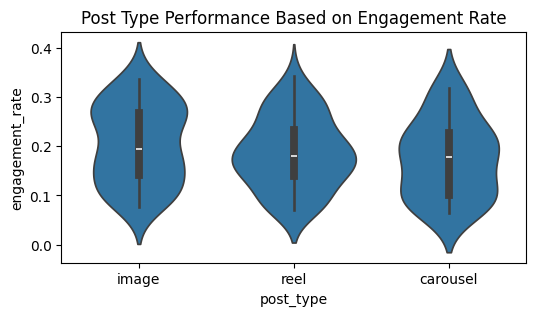

In [22]:
plt.figure(figsize=(6,3))
sns.violinplot(x='post_type',y='engagement_rate',data=df)
plt.title("Post Type Performance Based on Engagement Rate")
plt.show()

### Insight
- Image posts have slightly higher and more stable engagement compared to other post types.
- Reels also perform well, but their engagement is more mixed (some high, some low).
- Carousel posts usually get lower engagement compared to images and reels.

### Posting Hour VS Engagement_Rate

<function matplotlib.pyplot.show(close=None, block=None)>

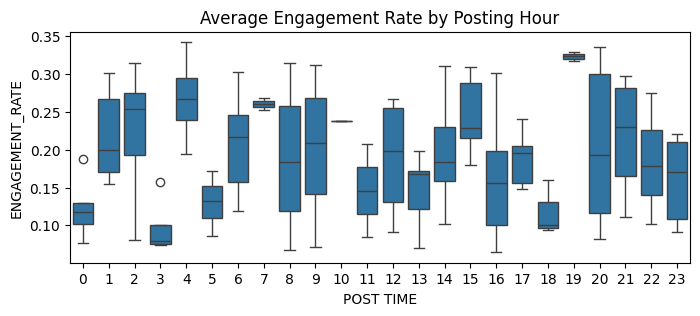

In [16]:
plt.figure(figsize=(8,3))
sns.boxplot(x='post_time',y='engagement_rate',data=df)
plt.title("Average Engagement Rate by Posting Hour")
plt.xlabel("POST TIME")
plt.ylabel("ENGAGEMENT_RATE")
plt.show

### Insight
- Posting content at 20:00 (8 PM) generate the highest engagement_rate.
- This indicates that audience is more active during this hour.
- Therefore,posting around 8pm can help to improve engagement performance


### Post_Type Based on Reach

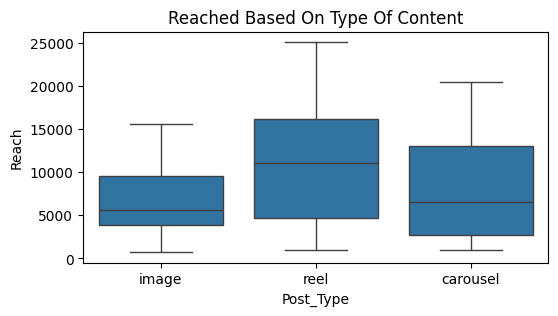

In [17]:
plt.figure(figsize=(6,3))
sns.boxplot(x='post_type',y='reach',data=df)
plt.title("Reached Based On Type Of Content")
plt.xlabel("Post_Type")
plt.ylabel("Reach")
plt.show()

### Insight
- This chart shows that Reels get the highest reach in compared to Images and Carousel.
- This indicates creating video based content is more effective in reaching to a larger audience.
- Therefore,focusing on Reels can help to increase overall content reach.

    

### Correlation Between Instagram Metrics

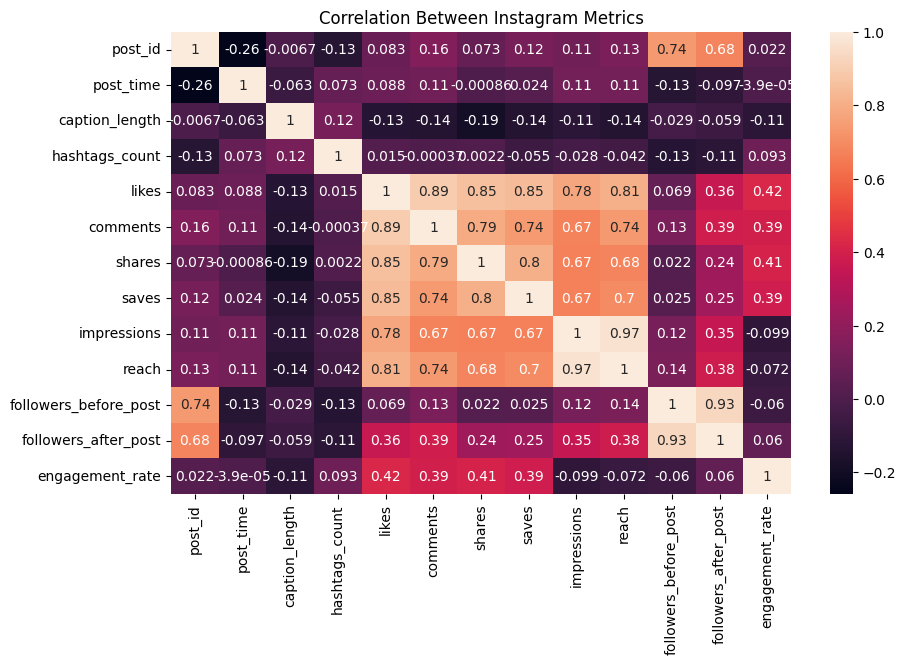

In [65]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Between Instagram Metrics")
plt.show()

### Insight

- Likes, comments, shares, and saves are strongly connected and tend to increase together.
- Reach and impressions are key drivers of engagement, as higher visibility leads to more interactions.
- Hashtags, caption length, and posting time show weak influence on engagement in this dataset.

### Engagement Rate Comparison Across Post Types

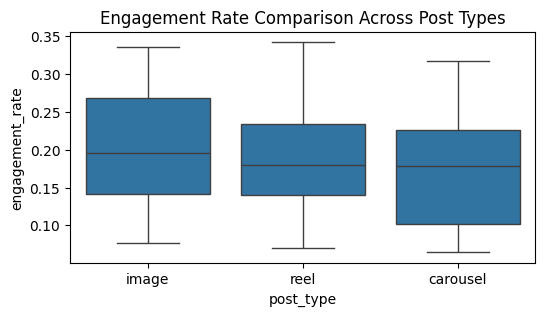

In [28]:
plt.figure(figsize=(6,3))
sns.boxplot(x='post_type',y='engagement_rate',data=df)
plt.title("Engagement Rate Comparison Across Post Types")
plt.show()

### Insight

- Reels perform best overall due to the highest reach and strong engagement potential.
- Image posts provide more consistent engagement performance across metrics.
- Carousel posts generally underperform compared to Reels and Images.

### Engagement Rate by Post Type and Posting Hour

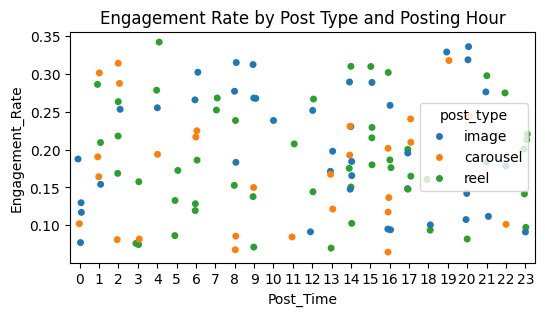

In [78]:
plt.figure(figsize=(6,3))
sns.stripplot(x='post_time',y='engagement_rate',hue='post_type',data=df)
plt.title("Engagement Rate by Post Type and Posting Hour")
plt.xlabel("Post_Time")
plt.ylabel("Engagement_Rate")
plt.show()

### Insight

- Engagement varies across posting hours, but no single time consistently performs best for all post types.
- Image posts show more stable engagement across different hours.
- Reels show higher variation, with strong performance at specific times.
- Carousel posts generally underperform across most time slots.

### Final Conclusion

- Reels generate the highest reach compared to other post types.
- Image posts are more consistent and achieve higher engagement across different posting hours.
- Carousel posts overall underperform in both reach and engagement.
- Posting content around 8 PM performs better and generates the highest engagement rate.

### Overall Insight

A combination of content types (Reels and Images) with optimal posting time (especially evening hours) leads to better engagement and reach. Additionally, content quality and visibility are much more important than caption length or hashtags in driving performance.